# Panama Electricity Demand: Getting to Know the Data

**Part 1** of a demand forecasting project built for a Data Scientist II application at Black Hills Energy.

**Data source:** [Short-term electricity load forecasting (Panama)](https://www.kaggle.com/datasets/ernestojaguilar/shortterm-electricity-load-forecasting-panama)  Aguilar Madrid (2021), via Kaggle/Mendeley.

Before building any predictive model, it's worth spending real time just looking at the data, checking it's trustworthy, spotting anything unusual, and understanding the patterns a model will eventually need to learn. That's what this notebook does:

1. Load the data and check it's actually clean
2. Look at the basic numbers, and flag anything that looks off
3. Plot demand over time
4. Split demand into simpler pieces (long-term trend, daily pattern, leftover noise)
5. Check how strongly demand today is related to demand in the recent past
6. See how weather and the calendar relate to demand
7. Look at demand patterns by hour, day of week, and holiday

Building the actual forecasting models comes in Part 2.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)


## 1. Load the data

The Kaggle archive contains a few files. This notebook uses:

- `continuous dataset.csv` — the main hourly file: national electricity demand (`nat_demand`, what we're trying to predict) plus weather readings from three cities and holiday/school calendar flags.
- `weekly pre-dispatch forecast.csv` — the utility's own official forecast, published in advance each week. We're keeping this aside as a real-world yardstick — in Part 2, we'll check whether our own models can do better than what the utility actually used.

If you're running this in Colab and haven't uploaded the files yet, the next cell will prompt you.


In [2]:
import os

DATA_DIR = "."

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

required_files = ["continuous dataset.csv", "weekly pre-dispatch forecast.csv"]
if IN_COLAB and not all(os.path.exists(os.path.join(DATA_DIR, f)) for f in required_files):
    from google.colab import files
    print("Upload 'continuous dataset.csv' and 'weekly pre-dispatch forecast.csv' from the Kaggle archive:")
    uploaded = files.upload()

df = pd.read_csv(os.path.join(DATA_DIR, "continuous dataset.csv"), parse_dates=["datetime"])
df = df.set_index("datetime").sort_index()

forecast = pd.read_csv(os.path.join(DATA_DIR, "weekly pre-dispatch forecast.csv"), parse_dates=["datetime"])
forecast = forecast.set_index("datetime").sort_index()

print(f"Demand data:  {df.shape[0]:,} rows  |  {df.index.min()} -> {df.index.max()}")
print(f"Forecast data: {forecast.shape[0]:,} rows  |  {forecast.index.min()} -> {forecast.index.max()}")
df.head()


Demand data:  48,048 rows  |  2015-01-03 01:00:00 -> 2020-06-27 00:00:00
Forecast data: 40,152 rows  |  2016-01-02 00:00:00 -> 2020-07-31 23:00:00


,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


## 2. Is the data actually clean?

Before trusting anything else, it's worth checking the basics: is every hour actually present with no gaps, are there any duplicate entries, and is anything blank? This is the same instinct as a Power Query column-quality check — just done with `pandas` instead of the Power Query UI.


In [3]:
full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
missing = full_range.difference(df.index)
dupes = df.index.duplicated().sum()
null_counts = df.isnull().sum()

print(f"Expected hourly readings: {len(full_range):,}")
print(f"Actual rows:              {len(df):,}")
print(f"Missing timestamps:       {len(missing)}")
print(f"Duplicate timestamps:     {dupes}")
print()
if null_counts.sum() == 0:
    print("No blank values in any column — the dataset is fully filled in.")
else:
    print("Blank values per column:")
    print(null_counts[null_counts > 0])


Expected hourly readings: 48,048
Actual rows:              48,048
Missing timestamps:       0
Duplicate timestamps:     0

No blank values in any column — the dataset is fully filled in.


**Result:** every hour from January 2015 through June 2020 is present, nothing is duplicated, and nothing is blank.


## 3. The basic numbers, and anything that looks off


In [4]:
print(df["nat_demand"].describe().round(1))


count    48048.0
mean      1182.9
std        192.1
min         85.2
25%       1020.1
50%       1168.4
75%       1327.6
max       1754.9
Name: nat_demand, dtype: float64


In [5]:
lowest = df["nat_demand"].nsmallest(8)
print("The 8 lowest demand readings in the whole dataset:")
print(lowest)


The 8 lowest demand readings in the whole dataset:
datetime
2019-01-20 12:00:00     85.1925
2019-01-20 13:00:00    135.7636
2019-01-20 14:00:00    263.6183
2017-06-27 12:00:00    380.5936
2019-01-20 15:00:00    417.4492
2019-01-20 16:00:00    475.8024
2015-01-24 17:00:00    509.8358
2017-07-01 14:00:00    560.7009
Name: nat_demand, dtype: float64


**Something unusual:** the eight lowest readings all cluster on **January 20, 2019**, where demand drops from a normal ~1,000+ MWh down to **85 MWh** around noon, then climbs back to normal over the next few hours. That's not a broken sensor or a data error. A real, nationwide power outage was reported in Panama on that exact date, three days before Pope Francis's visit for World Youth Day.

This matters for the modeling work ahead: left in as-is, this one unusual day could confuse a model into thinking it's a normal pattern rather than a one-off event.


## 4. Plotting demand over time


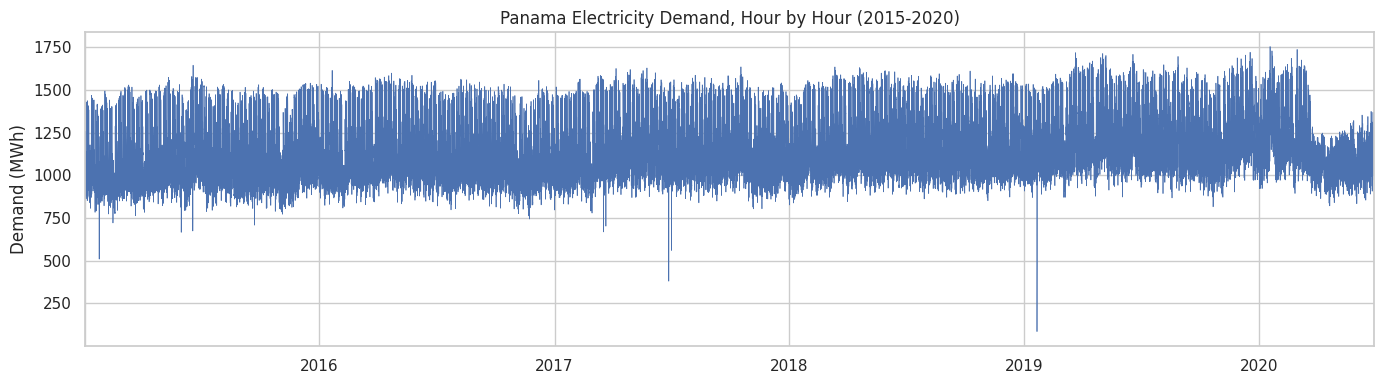

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
df["nat_demand"].plot(ax=ax, linewidth=0.5)
ax.set_title("Panama Electricity Demand, Hour by Hour (2015-2020)")
ax.set_ylabel("Demand (MWh)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


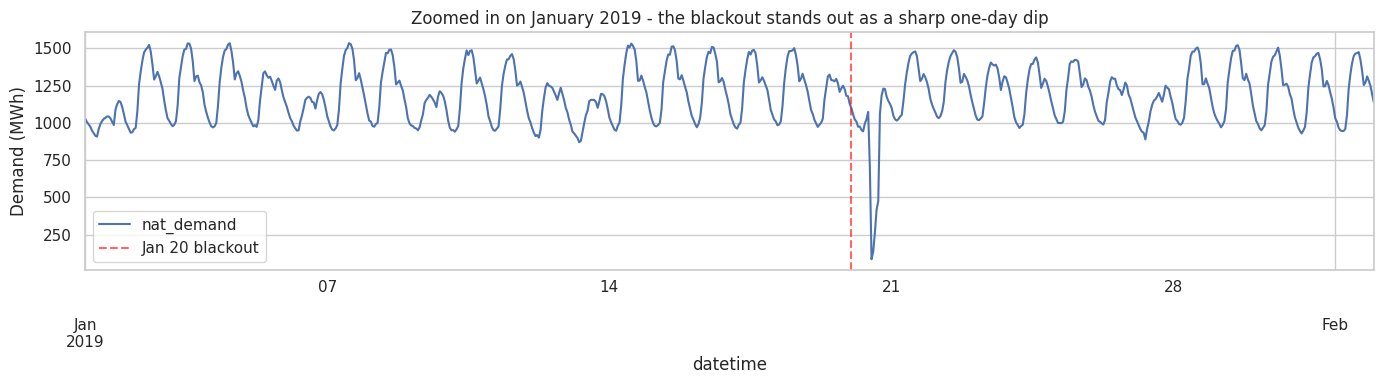

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
df.loc["2019-01-01":"2019-02-01", "nat_demand"].plot(ax=ax)
ax.axvline(pd.Timestamp("2019-01-20"), color="red", linestyle="--", alpha=0.6, label="Jan 20 blackout")
ax.set_title("Zoomed in on January 2019 - the blackout stands out as a sharp one-day dip")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()


Two things are already visible at a glance: demand is generally climbing over the five and a half years (more people, more usage, a growing grid), and there's a dense, repeating up-and-down pattern throughout, which is really the daily cycle compressed at this zoomed-out view. The second chart isolates the blackout as a single sharp dip against otherwise smooth daily ups and downs.


## 5. Splitting demand into simpler pieces

Electricity demand is really a few different patterns layered on top of each other:

- A **long-term trend** — is overall usage generally climbing or shrinking over the years?
- A **repeating daily pattern** — usage goes up during the day and drops at night, every single day.
- **Leftover noise** — everything that doesn't fit the first two, including one-off events like the blackout.

There's a well-established statistical technique (called STL) that automatically separates a time series into exactly these three pieces


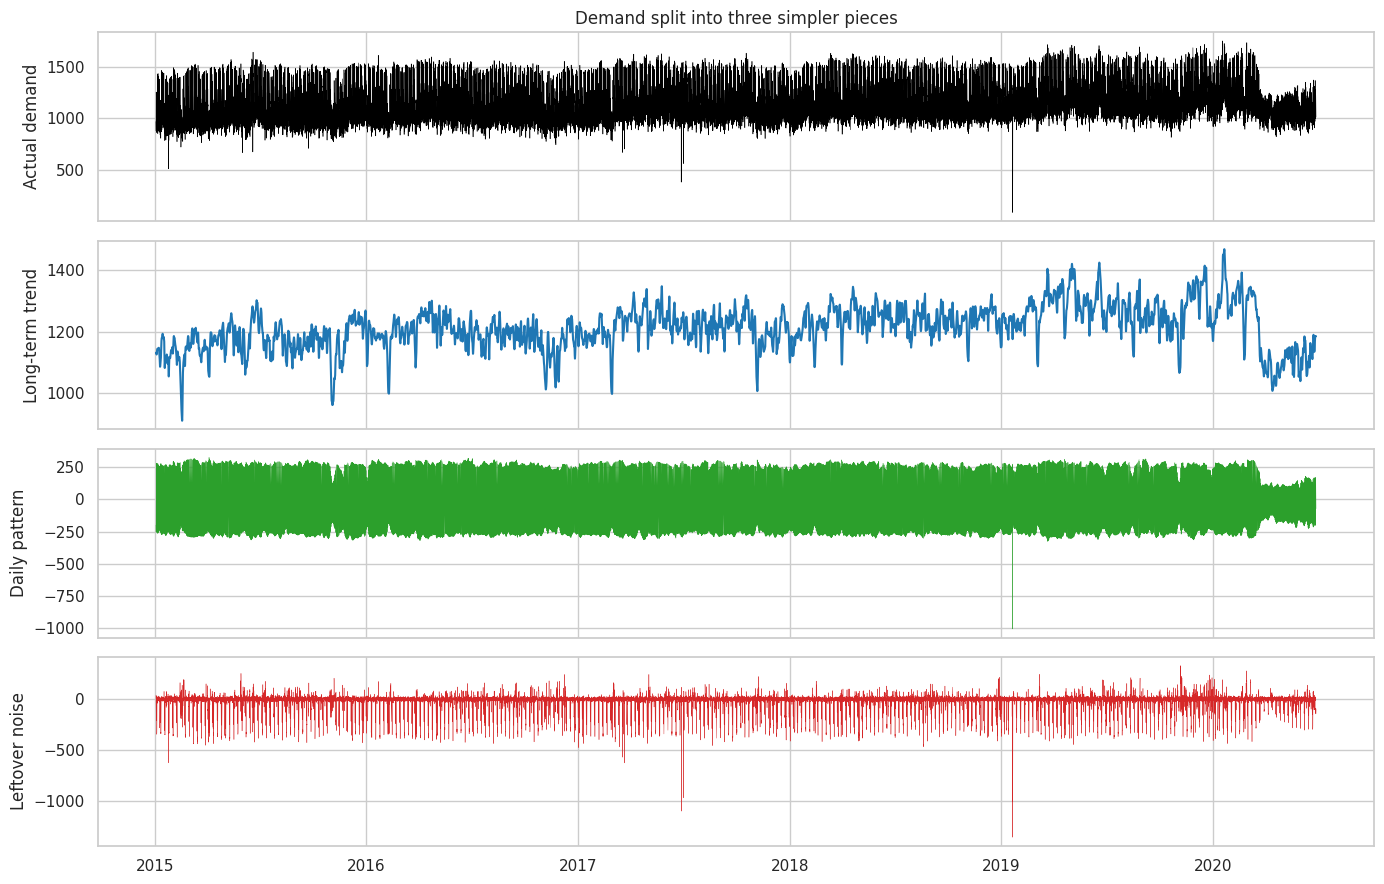

In [8]:
stl = STL(df["nat_demand"], period=24, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, stl_result.observed, color="black", linewidth=0.4)
axes[0].set_ylabel("Actual demand")
axes[0].set_title("Demand split into three simpler pieces")

axes[1].plot(df.index, stl_result.trend, color="tab:blue")
axes[1].set_ylabel("Long-term trend")

axes[2].plot(df.index, stl_result.seasonal, color="tab:green", linewidth=0.3)
axes[2].set_ylabel("Daily pattern")

axes[3].plot(df.index, stl_result.resid, color="tab:red", linewidth=0.3)
axes[3].set_ylabel("Leftover noise")

plt.tight_layout()
plt.show()


We told the tool to treat one-off events (like the blackout) as noise rather than let them distort our read on the "normal" trend and daily pattern — that's what `robust=True` does in the code above. It worked as intended: the **long-term trend** panel shows steady multi-year growth, the **daily pattern** panel shows a strong, stable repeating shape, and the blackout shows up cleanly in the **leftover noise** panel as a sharp spike, right where we'd expect it, rather than dragging down the trend or daily-pattern estimates.


## 6. How much does demand echo its own past?

Here's an intuitive question: if I know what demand looked like an hour ago, a day ago, or a week ago, how much does that actually tell me about right now?

The two charts below (their technical names are ACF and PACF, but the idea is simple) each show one bar per "distance back in time." A tall bar means demand at that distance back is strongly related to demand right now; a short bar means it isn't. This is exactly the kind of check that tells us which past values are actually worth using as inputs when we build a forecasting model in Part 2.


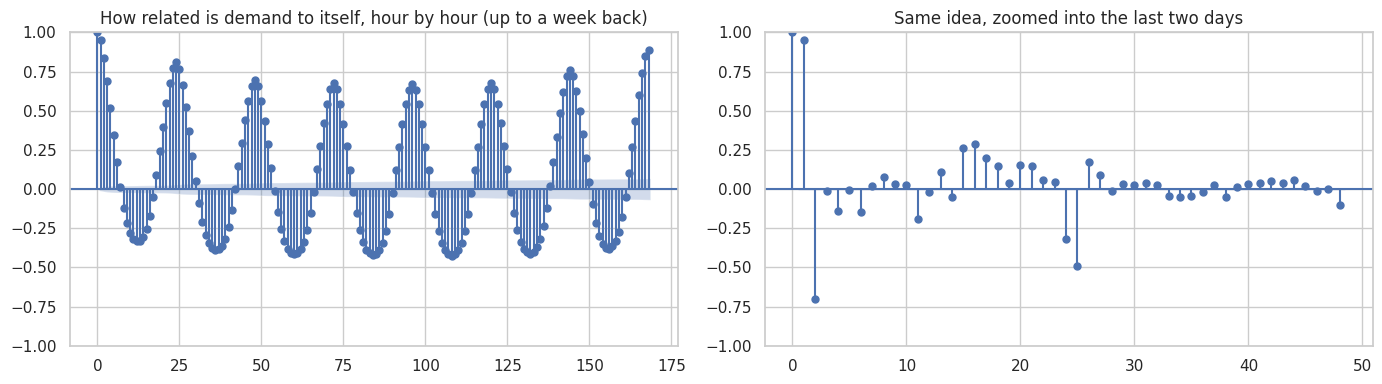

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["nat_demand"], lags=7*24, ax=axes[0])
axes[0].set_title("How related is demand to itself, hour by hour (up to a week back)")
plot_pacf(df["nat_demand"], lags=48, ax=axes[1], method="ywm")
axes[1].set_title("Same idea, zoomed into the last two days")
plt.tight_layout()
plt.show()


As expected, demand is most strongly related to itself at 24-hour intervals (yesterday at this hour, the day before at this hour, and so on), with a further bump at 168 hours — exactly one week ago. That's the evidence behind a design choice we'll make in Part 2: using "the same hour, N weeks ago" as an input to our forecasting models, rather than something arbitrary.


## 7. Does weather affect demand?


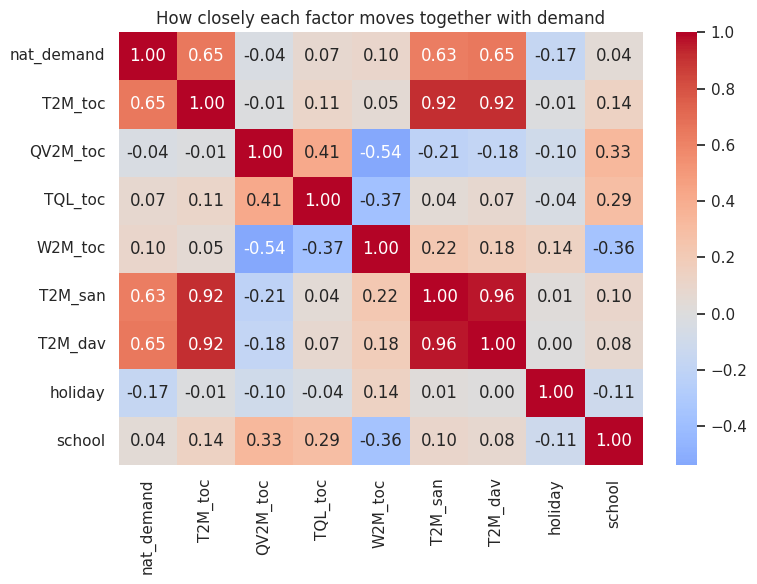

In [10]:
corr_cols = ["nat_demand", "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
             "T2M_san", "T2M_dav", "holiday", "school"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("How closely each factor moves together with demand")
plt.tight_layout()
plt.show()


Each number ranges from -1 to 1: closer to 1 (or -1) means the two things move together (or in opposite directions) very consistently; closer to 0 means there's not much of a relationship. Temperature usually shows the strongest weather relationship with electricity demand, since hotter weather means more air conditioning running — worth checking whether that holds true here, and across which of the three cities, since it tells us which weather readings are actually worth keeping as model inputs later.


## 8. Demand by time of day, day of week, and holidays


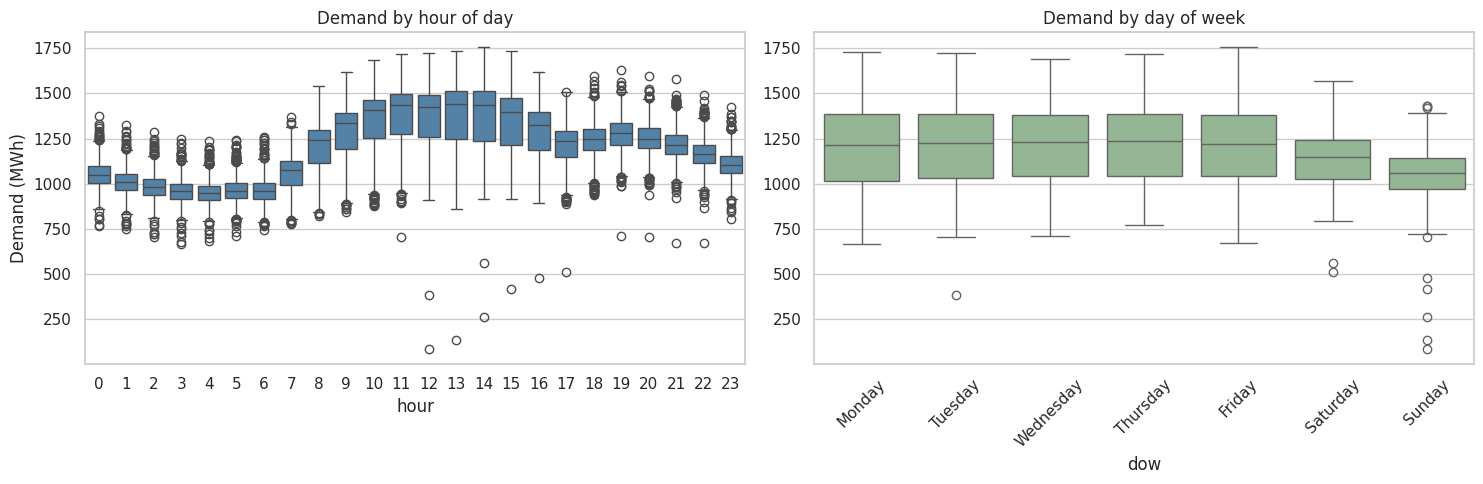

In [11]:
work = df.copy()
work["hour"] = work.index.hour
work["dow"] = work.index.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=work, x="hour", y="nat_demand", ax=axes[0], color="steelblue")
axes[0].set_title("Demand by hour of day")
axes[0].set_ylabel("Demand (MWh)")

sns.boxplot(data=work, x="dow", y="nat_demand", order=dow_order, ax=axes[1], color="darkseagreen")
axes[1].set_title("Demand by day of week")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [12]:
holiday_means = work.groupby("holiday")["nat_demand"].agg(["mean", "std", "count"])
holiday_means.index = ["Regular day", "Holiday"]
print(holiday_means.round(1))

school_means = work.groupby("school")["nat_demand"].agg(["mean", "std", "count"])
school_means.index = ["School vacation", "School in session"]
print()
print(school_means.round(1))


               mean    std  count
Regular day  1191.1  192.7  45024
Holiday      1060.1  131.6   3024

                     mean    std  count
School vacation    1170.3  189.6  13079
School in session  1187.6  192.8  34969


## What we now know

- The data is unusually clean: every hour is present from 2015-01-03 through 2020-06-27, nothing duplicated, nothing blank.
- One real anomaly (the January 20, 2019 nationwide blackout) needs a deliberate plan in the modeling stage, not a silent deletion.
- Demand has a clear, repeating daily pattern plus a multi-year upward trend confirmed both by eye and by the more formal decomposition and past-value checks above.
- Weather and calendar factors show a measurable relationship with demand, which supports using them as inputs later.
- The dataset's author already suggests 14 realistic test periods (in `train_dataframes.xlsx` / `test_dataframes.xlsx`), and includes the utility's real published forecast — giving us both a ready-made way to test fairly and a genuine benchmark to try to beat.

**Next up (Part 2):** turning these observations into actual forecasting models, tested the way they'd really be used.
